# OpenMesh Dataset — Quick Start

Download, load, and explore the OpenMesh wireless links and PWS datasets.

**Datasets:**
1. **Wireless Links** — RSL time series from NYC mesh network (Oct 2023 – Jul 2024)
2. **PWS** — Personal Weather Stations rainfall (sample: January / full: ~8 months)

## 1. Setup & Download

In [2]:
from OpenMesh_setup import download_all, load_links, load_pws, create_sample, print_summary

# Download both Zenodo datasets (skips if already downloaded)
download_all()

1/2  OpenMesh (wireless links + PWS sample)
  Already exists: OpenMesh.zip
  Already extracted: 3 NetCDF, 3 CSV files

2/2  PWS Weather Underground (full dataset)
  Already exists: PWS_NYC_WU.zip
  Already extracted: pws_wu_os.nc

Done. Data in:
  NetCDF:   /Users/drorjac/PycharmProjects/OpenMesh-fresh/dataset/raw/openmesh
  Metadata: /Users/drorjac/PycharmProjects/OpenMesh-fresh/dataset/meta


## 2. Load Wireless Links

In [3]:
ds_links, links_meta = load_links()
ds_links

Loaded links: 75 links, 354241 timesteps (2023-10-29 to 2024-07-01)


<xarray.Dataset> Size: 322MB
Dimensions:       (cml_id: 75, sublink_id: 3, time: 354241)
Coordinates:
  * time          (time) datetime64[ns] 3MB 2023-10-29 ... 2024-07-01
  * sublink_id    (sublink_id) object 24B 'sublink_1' 'sublink_2' 'sublink_3'
    site_0_lat    (cml_id) float32 300B ...
    site_0_lon    (cml_id) float32 300B ...
    site_1_lat    (cml_id) float32 300B ...
    site_1_lon    (cml_id) float32 300B ...
    length        (cml_id) float32 300B ...
    frequency     (cml_id, sublink_id) float32 900B ...
    polarization  (cml_id, sublink_id) object 2kB ...
  * cml_id        (cml_id) <U2 600B '1' '2' '3' '4' '5' ... '72' '73' '74' '75'
Data variables:
    rsl           (cml_id, sublink_id, time) float32 319MB ...
Attributes:
    title:                 OpenMesh
    file_author:           Dror Jacoby
    institution:           Cellular Environmental Monitoring (CellEnMon) Lab,...
    date:                  2025-11-01
    source:                Community NYC Mesh Wireless Network
    history:               2025-11-01: Updated metadata, converted netCDF → O...
    naming_convention:     OpenSense-1.0
    license_restrictions:  CC BY 4.0 – https://creativecommons.org/licenses/b...
    reference:             https://doi.org/10.5281/zenodo.15287692
    comment:               OpenMesh: Wireless Signal Dataset for Opportunisti...
    Conventions:           OpenSense-CML-v1.0

In [4]:
# Link metadata
links_meta.head()

,Unnamed: 0,cml_id,sublink_id,site_0_lat,site_0_lon,site_1_lat,site_1_lon,frequency,length,polarization
0,0,1,sublink_1,40.696093,-73.939749,40.686198,-73.917500,68040,2178.1,v
1,1,1,sublink_2,40.686139,-73.917512,40.696096,-73.939780,68040,2183.0,v
2,2,1,sublink_3,40.685983,-73.917588,40.696000,-73.939800,5765,2178.9,v
3,3,2,sublink_1,40.657782,-74.004848,40.682995,-73.993789,5545,2954.6,v
4,4,2,sublink_2,40.657955,-74.004929,40.683037,-73.993851,24100,2938.6,v


In [5]:
# Quick stats
import pandas as pd

print(f"Links:      {len(ds_links.cml_id)}")
print(f"Sublinks:   {len(ds_links.sublink_id)}")
print(f"Timesteps:  {len(ds_links.time):,}")
print(f"Period:     {str(ds_links.time.values[0])[:10]} to {str(ds_links.time.values[-1])[:10]}")
print(f"Resolution: {pd.Timedelta(ds_links.time.diff('time').median().values)}")

Links:      75
Sublinks:   3
Timesteps:  354,241
Period:     2023-10-29 to 2024-07-01
Resolution: 0 days 00:01:00


## 3. Load PWS Data

In [6]:
# Load sample (January) — included in OpenMesh.zip
pws_data, pws_meta = load_pws(sample=True)

print(f"Stations: {len(pws_data)}")
print(f"Station IDs: {list(pws_data.keys())[:5]}...")

Loaded PWS (sample): 37 stations from pws_opensense_sample_jan.nc
Stations: 37
Station IDs: ['KNYNEWYO1472', 'KNYNEWYO1659', 'KNYNEWYO1288', 'KNYNEWYO1896', 'KNYNEWYO1921']...


In [7]:
# Look at one station
station_id = list(pws_data.keys())[0]
ds_station = pws_data[station_id]
print(f"Station: {station_id}")
ds_station

Station: KNYNEWYO1472


<xarray.Dataset> Size: 282kB
Dimensions:            (time: 4402)
Coordinates:
  * time               (time) datetime64[ns] 35kB 2024-01-15T00:04:00 ... 202...
Data variables:
    rainfall_rate      (time) float64 35kB ...
    rainfall_amount    (time) float64 35kB ...
    temperature        (time) float64 35kB ...
    relative_humidity  (time) float64 35kB ...
    wind_velocity      (time) float64 35kB ...
    wind_direction     (time) float64 35kB ...
    air_pressure       (time) float64 35kB ...

In [8]:
# PWS metadata
if pws_meta is not None:
    pws_meta.head()

## 4. Plot Examples

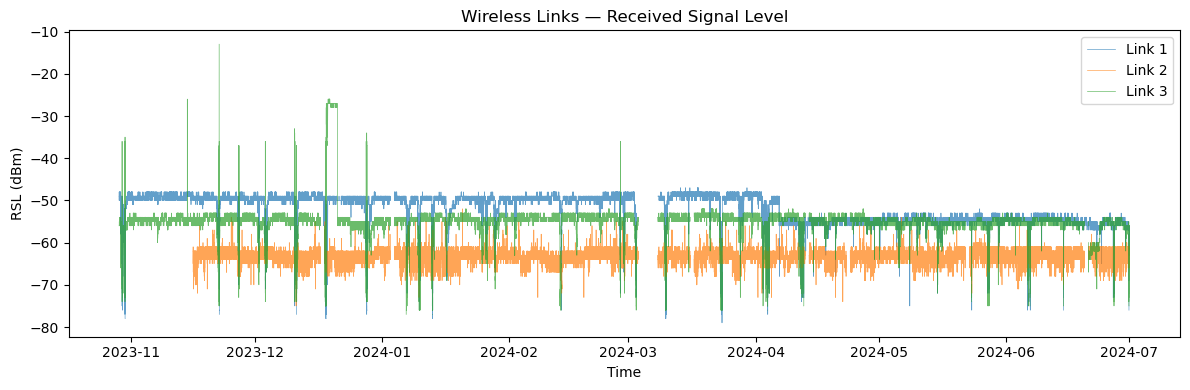

In [9]:
import matplotlib.pyplot as plt
import numpy as np

# --- Plot RSL for a few links ---
fig, ax = plt.subplots(figsize=(12, 4))
for link_id in ds_links.cml_id.values[:3]:
    rsl = ds_links.rsl.sel(cml_id=link_id, sublink_id='sublink_1')
    ax.plot(ds_links.time, rsl, label=f'Link {link_id}', alpha=0.7, linewidth=0.5)
ax.set_xlabel('Time')
ax.set_ylabel('RSL (dBm)')
ax.set_title('Wireless Links — Received Signal Level')
ax.legend()
plt.tight_layout()
plt.show()

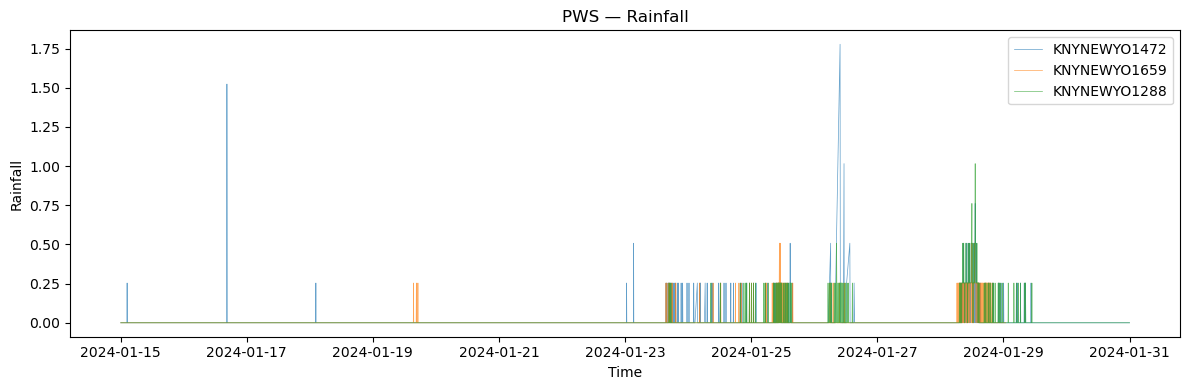

In [10]:
# --- Plot rainfall for a few PWS stations ---
fig, ax = plt.subplots(figsize=(12, 4))
for sid in list(pws_data.keys())[:3]:
    ds = pws_data[sid]
    if 'rainfall_amount' in ds:
        rain = ds.rainfall_amount
    elif 'rainfall_rate' in ds:
        rain = ds.rainfall_rate
    else:
        continue
    ax.plot(ds.time, rain, label=sid, alpha=0.7, linewidth=0.5)
ax.set_xlabel('Time')
ax.set_ylabel('Rainfall')
ax.set_title('PWS — Rainfall')
ax.legend()
plt.tight_layout()
plt.show()

## 5. Create a Sample Period

In [11]:
# Slice all datasets to a specific period
sample = create_sample('2024-01-15', '2024-01-30')

print_summary(sample['links'], sample['pws'])

Loaded links: 75 links, 354241 timesteps (2023-10-29 to 2024-07-01)
Loaded PWS (sample): 37 stations from pws_opensense_sample_jan.nc

Sample period: 2024-01-15 to 2024-01-30
  Links: 75 links, 21601 timesteps
  PWS:   37/37 stations with data in period
OpenMesh Dataset Summary

Wireless Links:
  Links:      75
  Sublinks:   3
  Timesteps:  21,601
  Period:     2024-01-15T00:00:00 → 2024-01-30T00:00:00
  Resolution: 0 days 00:01:00
  Variable:   rsl (Received Signal Level, dBm)

Personal Weather Stations:
  Stations:   37
  Period:     2024-01-15T00:04:00 → 2024-01-29T23:59:00
  Variable:   rainfall_amount


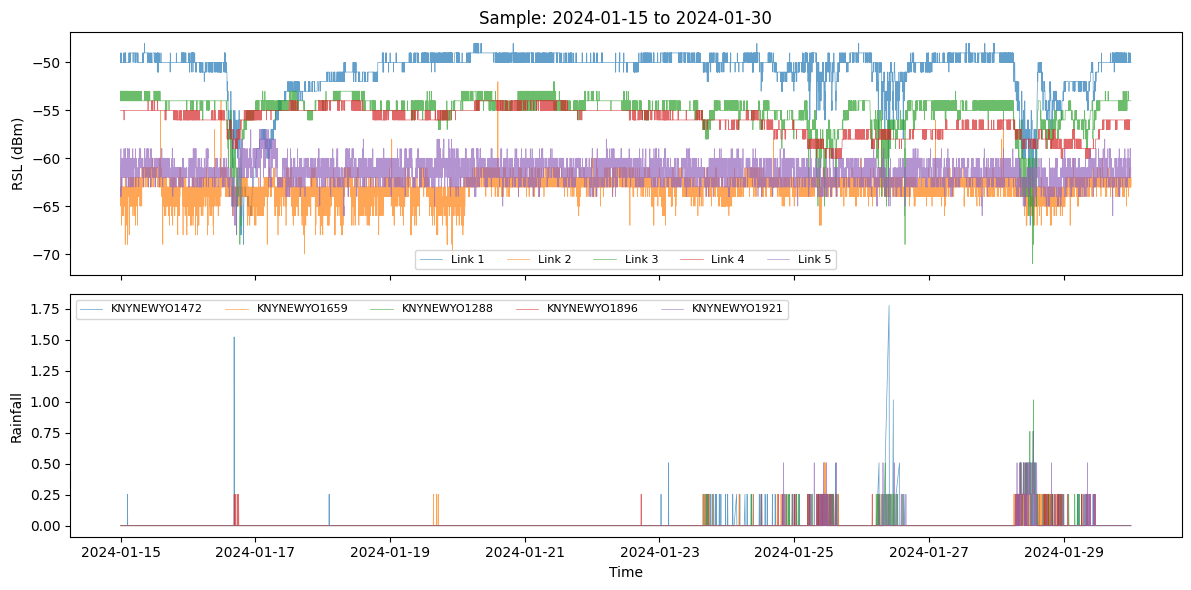

In [11]:
# Plot the sample period — links and PWS side by side
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 6), sharex=True)

# Links RSL
for link_id in sample['links'].cml_id.values[:5]:
    rsl = sample['links'].rsl.sel(cml_id=link_id, sublink_id='sublink_1')
    ax1.plot(sample['links'].time, rsl, alpha=0.7, linewidth=0.5, label=f'Link {link_id}')
ax1.set_ylabel('RSL (dBm)')
ax1.set_title(f"Sample: {sample['start']} to {sample['end']}")
ax1.legend(fontsize=8, ncol=5)

# PWS rainfall
for sid, ds in list(sample['pws'].items())[:5]:
    rain_var = 'rainfall_amount' if 'rainfall_amount' in ds else list(ds.data_vars)[0]
    ax2.plot(ds.time, ds[rain_var], alpha=0.7, linewidth=0.5, label=sid)
ax2.set_ylabel('Rainfall')
ax2.set_xlabel('Time')
ax2.legend(fontsize=8, ncol=5)

plt.tight_layout()
plt.show()

## 6. Direct NetCDF Access

You can also load the data directly without `OpenMesh_setup`:

In [12]:
import xarray as xr
import netCDF4 as nc
from pathlib import Path

data_dir = Path('../../raw/openmesh')  # from dataset/examples/read_OpenMesh/

# Wireless links
ds = xr.open_dataset(data_dir / 'ds_openmesh.nc')
print(f"Links: {len(ds.cml_id)} links, {len(ds.time)} timesteps")
print(f"Variables: {list(ds.data_vars)}")

# PWS — list station groups
with nc.Dataset(data_dir / 'pws_opensense_sample_jan.nc', 'r') as nf:
    stations = list(nf.groups.keys())
print(f"\nPWS stations: {len(stations)}")

# Load one station
ds_pws = xr.open_dataset(data_dir / 'pws_opensense_sample_jan.nc', group=stations[0])
print(f"Station {stations[0]}: {list(ds_pws.data_vars)}")

Links: 75 links, 354241 timesteps
Variables: ['rsl']

PWS stations: 37
Station KNYNEWYO1472: ['rainfall_rate', 'rainfall_amount', 'temperature', 'relative_humidity', 'wind_velocity', 'wind_direction', 'air_pressure']
